In [18]:
%pip install pandas matplotlib tabulate numpy statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import re
from difflib import SequenceMatcher
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from tabulate import tabulate
#import ast

In [ ]:
cwes = ["CWE-22", "CWE-89", "CWE-79"]
# cwes = ["CWE-79"]
models = ['mixtral-8x7b-32768', 'mixtral-8x22b-65536', "llama3-70b-8192", "gpt-3.5-turbo", "gpt-4-turbo", "gpt-4o"]
# models = ['mixtral-8x7b-32768']
# models = ["gpt-3.5-turbo"]

model_renames = {
    "mixtral-8x7b-32768": "mixtral-8x7b",
    "mixtral-8x22b-65536": "mixtral-8x22b",
    "llama3-70b-8192": "llama-3-70b",
}

- Usage -> define your models and skip to execution part
- The files must have structure data-CWE-XX-model.csv with following 3 headers: file_id, model_output, type (buggy, not_buggy)

# Functions

## importing CVS

In [21]:
def import_csv(cwe_id, model):

    def _check_files(df_data, df_files):
        # check if df_data has 3 columns: file_Id with integers, model_output with text and type with buggy/not_buggy
        required_columns = {
        'file_id': 'int64',  # assuming file_id should be an integer type
        'model_output': 'object', # in pd text
        'type': 'object'  
        }

        # Check if all required columns are in df_data and have the correct data type
        for column, dtype in required_columns.items():
            assert column in df_data.columns, f"Missing column: {column}"
            assert df_data[column].dtype == dtype, f"Incorrect dtype for {column}: expected {dtype}, found {df_data[column].dtype}"

        # Check if 'type' column has only 'buggy' or 'not_buggy'
        valid_types = ['buggy', 'not_buggy']
        assert df_data['type'].isin(valid_types).all(), "Column 'type' contains invalid entries"

        
        # Expected checks
        file_ids_data = df_data['file_id'].value_counts()
        file_ids_files = df_files['file_id'].unique()

        # Check for each file_id if it appears twice in the data
        problems = []
        for file_id in file_ids_files:
            if file_id not in file_ids_data or file_ids_data[file_id] != 2:
                problems.append(file_id)
        
        # Check if the number of records in data is double the number of file_ids in files
        if len(df_data) != 2 * len(df_files):
            print(f"Data count mismatch: Expected {2 * len(df_files)}, got {len(df_data)}.")

        if problems:
            print(f"Some file_ids are missing the required number of entries in the data:")
            for file_id in problems:
                count = file_ids_data[file_id] if file_id in file_ids_data else 0

                # Uncomment to see which files are exactly missing
                # print(f"file_id {file_id}: Expected 2, Found {count}")
        else:
            print("All file_ids have the correct number of entries.")

    # File paths
    data_csv = f"./model_outputs/data_{cwe_id}_{model}.csv"
    files_csv = f"./cve_data/files_{cwe_id}.csv"

    # Load data
    df_data = pd.read_csv(data_csv)
    df_files = pd.read_csv(files_csv)

    _check_files(df_data, df_files)

    # Continue processing as before
    df = pd.merge(df_data, df_files, on='file_id', how='left')
    df['file_to_use'] = df.apply(lambda row: row['file_before'] if row['type'] == 'buggy' else row['file_after'], axis=1)
    #df['file_to_use'] = list(map('\n'.join, map(ast.literal_eval, df['file_to_use'].tolist()))) # convert list of lines into entire file
    df = df[['file_to_use', 'type', 'model_output', 'patch']]

    return df


## Classification

In [22]:
# Functions to work towards classification
bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)
# enhanced regrex which removes notes and matches everything up to bug found: -> not working for notes etc, but takes  abckticks into account
# bug_line_pattern = re.compile(r'BL:\s*(?:`([^`]+)`|([^`]*?))(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# -> now logic defines in extract_bug_lines logic

def extract_code_or_return_original(text):
    # This regex matches text enclosed in triple backticks, capturing the content after the initial language specifier.
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        # No code block found, return the original text
        return text

    # If matches are found, extract and return them
    results = []
    for match in matches:
        # Extract the code content, excluding the language name
        results.append(match.group(2).strip())

    # Join extracted code blocks with newlines, if there are multiple blocks
    return "\n".join(results)

def clean_whitespace(text):
    # Replace all newlines with a single space
    text = text.replace('\n', ' ')
    # Replace all sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    # Extract lines starting with -
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    # Remove the leading - character from each line
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    # todo maybe not right? -> look then into df's
    # if there is second from the end take it otherwise the last one

    # TODO this is fix for second prompt where we have no BUG FOUND: -> maybe we should have a better check for this
    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    # bug_line = re.split(bug_line_pattern, model_output, 1)[-2]
    bug_line = extract_code_or_return_original(bug_line).strip()

    # if there is a string which is in ` ` extract it, otherwise use as it is
    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)  # Return content inside the backticks

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    _has_bug_line = bool(bug_line_pattern.search(model_output)) #or bool(bug_line_pattern_simple.search(model_output))

    # TODO might need some improval on this 
    if not _has_bug_line:
        return False
    
    # extract bug line
    bug_line = extract_bug_line(model_output)
    # strip remove spaces
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

def clean_patch(patch):
    # remova all + and - at the behinning of lines
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

def classify(record):
    type = record['type']
    patch = record['patch']
    model_output = record['model_output']

    classification = None
    bug_line = None
    patch_removal = None

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy':
        if has_bug_true_indication: 
            classification = 'FP'
        else:
            classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    else:
        # weaker decision based in bugged_line
        if not _has_bug_line:
            classification = 'FN'
        else:
            bug_line = remove_spaces(extract_bug_line(model_output))
            # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
            cleaned_patch = remove_spaces(clean_whitespace(clean_patch(patch)))

            bug_line_in_patch = bug_line in cleaned_patch

            if (len(bug_line) > 0 and bug_line_in_patch):
                classification = 'TP'
            else:
                classification = 'FN' 
        
    # return panda seried for easier debugging
    return pd.Series([classification, bug_line, patch_removal])

def get_patch_line_list(patch_text):
    patch_line_regexp = r'@@ -(\d+,\d+) \+(\d+,\d+) @@' # Regular expression pattern to match line numbers in the diff

    matches = re.findall(patch_line_regexp, patch_text)
    line_numbers = [int(match[0].split(',')[0]) for match in matches]
    return line_numbers

def get_first_patchline(patch):
    # Regular expression pattern to match the first -1 number in the diff
    lines = get_patch_line_list(patch)

    if(lines):
        return lines[0]

    return None  # Return None if no match is found to indicate the absence of the expected pattern

def extract_removed_lines(patch_text):
    lines = patch_text.split('\n')
    removed_lines = []
    current_line_number = 0

    for line in lines:
        # Match the hunk header to find the starting line number
        if line.startswith('@@'):
            match = re.match(r'@@ -(\d+),(\d+) \+(\d+),(\d+) @@', line)
            if match:
                current_line_number = int(match.group(1)) - 1
            continue

        # Increment line number for original file lines
        if line.startswith('-') or (not line.startswith('+') and not line.startswith('@')):
            current_line_number += 1

        # Process only lines that start with '-'
        if line.startswith('-'):
            removed_lines.append((current_line_number, line[1:].strip()))

    return removed_lines

## Logistic Regression

In [23]:
def calculate_stats(df):
    fn = df[df['classification'] == 'FN'].shape[0]
    fp = df[df['classification'] == 'FP'].shape[0]
    tn = df[df['classification'] == 'TN'].shape[0]
    tp = df[df['classification'] == 'TP'].shape[0]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    
    return {
        'Total records': df.shape[0],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

def print_stats(data):
    items = [[key, value] for key, value in data.items()]
    headers = ["Metric", "Value"]
    print(tabulate(items, headers=headers, tablefmt="grid"))

from sklearn.metrics import roc_auc_score, roc_curve
def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)

    # Calculate AUC using actual data
    individual_probs = model.predict(X)
    auc = roc_auc_score(y, individual_probs)

    # Retrieve model coefficients
    coefficients = model.params
    
    # Set label for plot (includes model details)
    label_dict = {
        "CWE-22": "CWE-22",
        "CWE-89": "CWE-89",
        "CWE-79": "CWE-79"
    }
    
    # Define line styles for each CWE for differentiation
    line_styles = {
        'CWE-22': 'solid',  # solid line
        'CWE-89': 'dashed', # dashed line
        'CWE-79': 'dashdot' # dash-dot line
    }
    
    # plot_label = f"{label_dict[label]} (p={coefficients[x_col]:.5f}, AUC={auc:.3f}, Intercept = {model.params['const']:.4f})"
    plot_label = f"{label_dict[label]} (p={model.pvalues[x_col]:.3f})"
    
    # Plot
    ax.plot(x_values, y_probs, label=plot_label, linestyle=line_styles[label], color=color, linewidth=2)
    
    # # Plot actual points
    # ax.scatter(data[x_col], individual_probs, color=color, alpha=0.3)  # semi-transparent
    
    # # Select five points to label and collect for DataFrame
    # sample_indices = np.linspace(0, len(data) - 1, 5, dtype=int)
    # points_df = pd.DataFrame({
    #     'x_value': data.iloc[sample_indices][x_col],
    #     'probability': individual_probs.iloc[sample_indices],
    #     'plot_name': label
    # }).reset_index(drop=True)

    # # Annotate the plot with these probabilities
    # for i, row in points_df.iterrows():
    #     ax.annotate(f'{row["probability"]:.2f}', 
    #                 (row['x_value'], row['probability']),
    #                 textcoords="offset points", 
    #                 xytext=(0,10), 
    #                 ha='center', 
    #                 fontsize=8, 
    #                 color=color)
   
    return model

def get_bug_pos(file_content, patch):
    patch_lines = get_patch_line_list(patch)
    if not patch_lines:
        return None, None, None
    file_content_lines = file_content.split('\n')
    min_bug_pos = len('\n'.join(file_content_lines[:patch_lines[0]]))
    #print(patch_lines, len(file_content_lines), len(file_content), min_bug_pos)
    max_bug_pos = len('\n'.join(file_content_lines[:patch_lines[-1]]))
    avg_bug_pos = (min_bug_pos+max_bug_pos)//2

    return min_bug_pos, max_bug_pos, avg_bug_pos

def calculate_outlier_thresholds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [24]:
def prepare_df(df):
    df[['classification', 'bug_line', 'patch_removal']] = df.apply(classify, axis=1)

    df['bug_pos'] = df.apply(lambda row: get_bug_pos(row['file_to_use'], row['patch'])[0], axis=1) #using 0 for min position


    df['patch_removal'] = df.apply(lambda row: get_removed_lines(row['patch']), axis=1)
    df['match_score_pure_removal'] = df.apply(lambda row: SequenceMatcher(None, row['patch_removal'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    df['match_score'] = df.apply(lambda row: SequenceMatcher(None, row['patch'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    #calculate important stats for regression 
    df['file_length_chars'] = df.apply(lambda row: len(row['file_to_use']), axis=1)

    
    df['patch_line_first'] = df.apply(lambda row: get_first_patchline(row['patch']), axis=1)
    df['removed_lines'] = df.apply(lambda row: extract_removed_lines(row['patch']), axis=1)

    return df       

# Line Plots - Trends

All file_ids have the correct number of entries.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:
All file_ids have the correct number of entries.
All file_ids have the correct number of entries.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 210, got 200.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 292, got 257.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 1086, got 985.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 210, got 208.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 292, got 286.
Some f

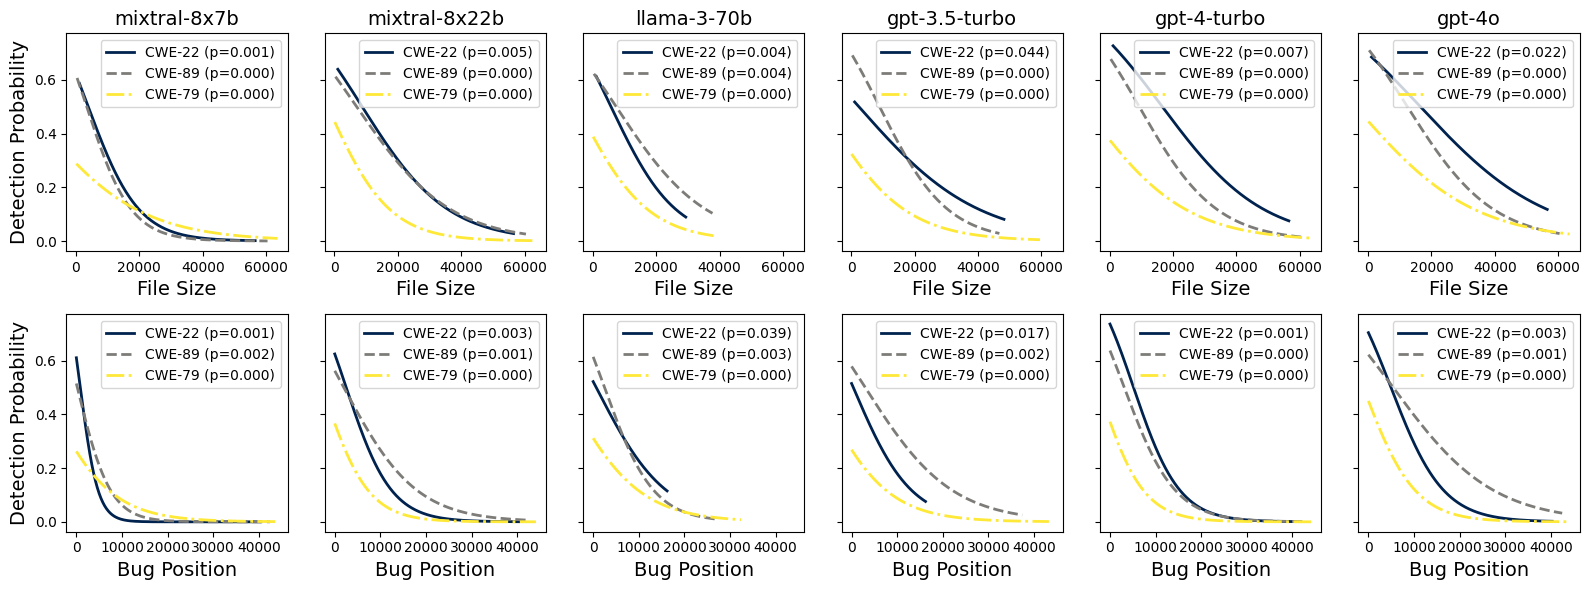

In [25]:
performance_summary = []
target_variable = 'classification_TP'
fontsize = 14

# Define figure size and number of subplots based on the number of models
fig, big_axes = plt.subplots(nrows=2, ncols=len(models), figsize=(16, len(models)), dpi=100, sharex='row', sharey='all')
fig.subplots_adjust(hspace=0.4, wspace=0.3)  # Adjust spacing between plots
colors = plt.cm.cividis(np.linspace(0, 1, len(cwes)))  # Generate a color array

df_all = pd.DataFrame()
for col, model in enumerate(models):
    for i, cwe in enumerate(cwes):
        ax1 = big_axes[0, col]
        ax2 = big_axes[1, col]

        try:
            df = import_csv(cwe, model)
            df = prepare_df(df)
            df['CWE-ID'] = cwe
            stats = calculate_stats(df)
            df = pd.get_dummies(df, columns=['classification'], drop_first=False)
            # performance summary append model, CWE, f1, accuracy, precision, recall\n",
            performance_summary.append({
                'model': model,
                'CWE': cwe,
                'F1': stats['F1'],
                'Accuracy': stats['Accuracy'],
                'Precision': stats['Precision'],
                'Recall': stats['Recall'],
                'Number of Samples': stats['Total records'],
            })
            df = df.dropna(subset=['bug_pos', 'file_length_chars'])
            df = df[(df['classification_TP'] == 1) | (df['classification_FN'] == 1)]
            #thresholds = calculate_outlier_thresholds(df['bug_pos'])
            #df = df[df['bug_pos'] <= 2 * thresholds[1]]

            if col == len(models)-1:
                df_all = pd.concat([df_all, df], axis=0)

            plot_logistic_regression(df, 'file_length_chars', target_variable, cwe, ax1, colors[i])
            plot_logistic_regression(df, 'bug_pos', target_variable, cwe, ax2, colors[i])

        except Exception as e:
            print(f"Error processing {cwe} with {model}: {str(e)}")

        # Setting titles, labels, and legends compactly
        # Renaming models
        ax1.set_title(model_renames.get(model,model), fontsize=fontsize)
        #ax2.set_title(model, fontsize=10)
        ax1.set_xlabel('File Size', fontsize=fontsize)
        ax2.set_xlabel('Bug Position', fontsize=fontsize)
        if col == 0:
            ax1.set_ylabel('Detection Probability', fontsize=fontsize)
            ax2.set_ylabel('Detection Probability', fontsize=fontsize)
        ax1.legend(fontsize=10)
        ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("./results/logistic_regression_all_models.pdf")
plt.show()

# performance summary to csv
performance_summary_df = pd.DataFrame(performance_summary)    
performance_summary_df.to_csv('./results/performance_summary.csv', index=False) 

Compute the average line size (chars).

In [26]:
all_sizes = []
for f in df_all['file_to_use']:
    all_sizes += map(len,f.split('\n'))
print('Average line size (chars):',np.mean(all_sizes))

Average line size (chars): 34.15748896707482


# Violin Plot - Chars Distribution

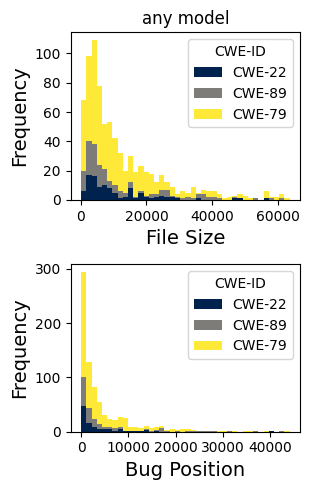

In [27]:
# Define figure size and create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(3.2, 5), dpi=100)
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Define colors
colors = plt.cm.cividis(np.linspace(0, 1, len(cwes)))

# Histogram bins
bins_file_length = np.linspace(df_all['file_length_chars'].min(), df_all['file_length_chars'].max(), 41)
bins_bug_pos = np.linspace(df_all['bug_pos'].min(), df_all['bug_pos'].max(), 41)

# Create a stacked histogram for file lengths
ax_file_length = axes[0]
data_to_stack = [df_all[df_all['CWE-ID'] == cwe]['file_length_chars'].values for cwe in cwes]
ax_file_length.hist(data_to_stack, bins=bins_file_length, stacked=True, color=colors, label=cwes, orientation='vertical')
ax_file_length.set_xlabel('File Size', fontsize=fontsize)
#ax_file_length.set_title('File Size Distribution')
ax_file_length.set_title('any model')
ax_file_length.set_ylabel('Frequency', fontsize=fontsize)
ax_file_length.legend(title='CWE-ID')

# Add more x-ticks
#ax_file_length.set_xticks(np.arange(0, ax_file_length.get_xlim()[1] + 1, 10000))
#ax_file_length.set_xticklabels(np.arange(0, int(ax_file_length.get_xlim()[1]) + 1, 10000), rotation=45)

# Add more y-ticks
#ax_file_length.set_yticks(np.arange(0, ax_file_length.get_ylim()[1] + 1, 25))
#ax_file_length.set_yticklabels(np.arange(0, int(ax_file_length.get_ylim()[1]) + 1, 25))

# Create a stacked histogram for bug positions
ax_bug_pos = axes[1]
data_to_stack = [df_all[df_all['CWE-ID'] == cwe]['bug_pos'].values for cwe in cwes]
ax_bug_pos.hist(data_to_stack, bins=bins_bug_pos, stacked=True, color=colors, label=cwes, orientation='vertical')
ax_bug_pos.set_xlabel('Bug Position', fontsize=fontsize)
#ax_bug_pos.set_title('Bug Position Distribution')
ax_bug_pos.set_ylabel('Frequency', fontsize=fontsize)
ax_bug_pos.legend(title='CWE-ID')

# Add more x-ticks
#ax_bug_pos.set_xticks(np.arange(0, ax_bug_pos.get_xlim()[1] + 1, 10000))
#ax_bug_pos.set_xticklabels(np.arange(0, int(ax_bug_pos.get_xlim()[1]) + 1, 10000), rotation=45)

# Add more y-ticks
#ax_bug_pos.set_yticks(np.arange(0, ax_bug_pos.get_ylim()[1] + 1, 40))
#ax_bug_pos.set_yticklabels(np.arange(0, int(ax_bug_pos.get_ylim()[1]) + 1, 40))


plt.tight_layout()
plt.savefig("./results/chars_distribution.pdf")
plt.show()

In [28]:
# TESTING

# manual testing of one loop -> good for comparing responses and patch on given CWE (in jupyter variables)
# df = import_csv('CWE-22', 'llama3-70b-8192')
df = import_csv('CWE-22', 'gpt-3.5-turbo')
df = prepare_df(df)
df['bug_pos']
# calculate_outlier_thresholds(df['bug_pos'])
stats = calculate_stats(df) #prints statistics about data coming into regression
print(stats)
print(print_stats(stats))

# fur for each models and for each CWE, then merge the DF togehter
# total_df = pd.DataFrame()
# for model in models:
#     for cwe in cwes:
#         try:
#             df = import_csv(cwe, model)
#             df = prepare_df(df)
#             # add column with model and cwe
#             df['model'] = model
#             df['cwe'] = cwe
#             total_df = pd.concat([total_df, df])
#         except FileNotFoundError:
#             print(f"Missing file for {cwe} with {model}")
# # export to excel
# total_df.to_excel('total_df.xlsx')

# # extract model gpt-3.5-turbo
# # groupt by CWE
# # showcount of values where coherent is true
# df = total_df[total_df['model'] == 'gpt-3.5-turbo']
# df = df.groupby('cwe')['coherent'].value_counts().unstack().fillna(0)
# # difive values by 2
# df = df / 2
# print(df)


Data count mismatch: Expected 210, got 208.
Some file_ids are missing the required number of entries in the data:
{'Total records': 208, 'Accuracy': 0.21153846153846154, 'Precision': 0.2916666666666667, 'Recall': 0.40384615384615385, 'F1': 0.33870967741935487}
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total records | 208        |
+---------------+------------+
| Accuracy      |   0.211538 |
+---------------+------------+
| Precision     |   0.291667 |
+---------------+------------+
| Recall        |   0.403846 |
+---------------+------------+
| F1            |   0.33871  |
+---------------+------------+
None
